In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
zip_path = "/content/drive/MyDrive/AI_ML/Data/Copy of devnagari digit.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted!")

ZIP Extracted!


In [4]:
base_path = "/content/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

img_size = 28

In [5]:
def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((28, 28))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)
            except:
                continue

    return np.array(images), np.array(labels)


In [17]:
print(sorted(os.listdir(test_dir)))


['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [6]:
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (17000, 28, 28, 1)
Test shape: (3000, 28, 28, 1)


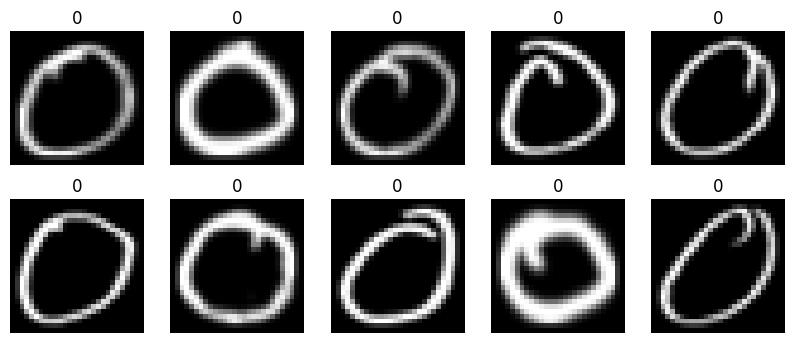

In [7]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')
plt.show()


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4929 - loss: 1.6223 - val_accuracy: 0.0000e+00 - val_loss: 6.9500
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8577 - loss: 0.4918 - val_accuracy: 0.0000e+00 - val_loss: 8.2252
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9280 - loss: 0.2554 - val_accuracy: 0.0000e+00 - val_loss: 8.8968
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9476 - loss: 0.1783 - val_accuracy: 0.0000e+00 - val_loss: 9.1813
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9612 - loss: 0.1365 - val_accuracy: 0.0000e+00 - val_loss: 9.4922
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9686 - loss: 0.1109 - val_accuracy: 0.0000e+00 - val_loss: 9.4518
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9726 - loss: 0.0958 - val_accuracy: 0.0000e+00 - val_loss: 9.8309
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9774 - 

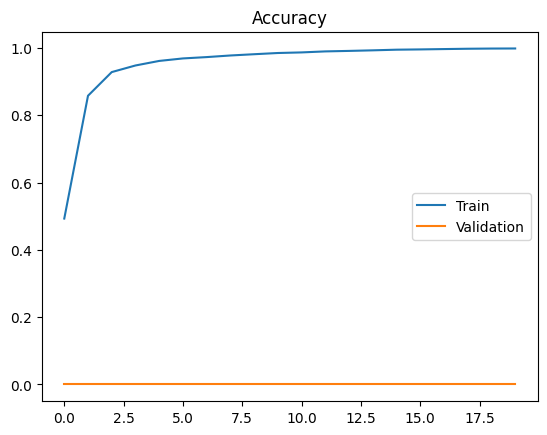

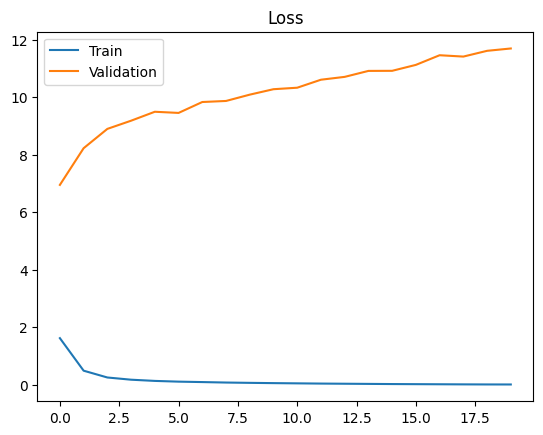

In [11]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7830 - loss: 2.3992
Test Accuracy: 0.7829999923706055


In [13]:
model.save("/content/drive/MyDrive/devnagari_model.h5")
print("Model Saved to Drive!")


Model Saved to Drive!


In [14]:
loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/devnagari_model.h5"
)

# re-evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7830 - loss: 2.3992
Loaded Model Accuracy: 0.7829999923706055


In [15]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: 0
Actual: 0


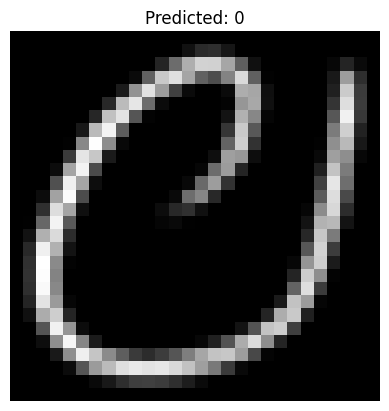

In [16]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_labels[0]}")
plt.axis('off')
plt.show()